# Task 5: Exploratory Data Analysis (EDA)

In [4]:
import pandas as pd

## Objective: Extract insights using visual and statistical exploration. 

## Tools: Python (Pandas, Matplotlib, Seaborn) 

## Phase 1: Dataset Understanding

### Step 1 - Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2 - Load Dataset

In [6]:
df = pd.read_csv("tested.csv")

### Step 3 - First Look

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### Step 4 - Dataset Shape

In [17]:
df.shape

(418, 12)

### Step 5 - Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


### Step 6

In [10]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


## Phase 2: Data Quality Check

In [19]:
# Missing Values
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [21]:
# Duplicate Records
df.duplicated().sum()

np.int64(0)

In [24]:
# Unique Values
df.nunique()

PassengerId    418
Survived         2
Pclass           3
Name           418
Sex              2
Age             79
SibSp            7
Parch            8
Ticket         363
Fare           169
Cabin           76
Embarked         3
dtype: int64

In [11]:
df['Sex'].value_counts()

Sex
male      266
female    152
Name: count, dtype: int64

In [12]:
df['Survived'].value_counts()

Survived
0    266
1    152
Name: count, dtype: int64

In [13]:
df['Pclass'].value_counts()

Pclass
3    218
1    107
2     93
Name: count, dtype: int64

In [14]:
df['Embarked'].value_counts()

Embarked
S    270
C    102
Q     46
Name: count, dtype: int64

## Phase 3: Univariate Analysis

## 1️⃣ Age Distribution (Histogram)

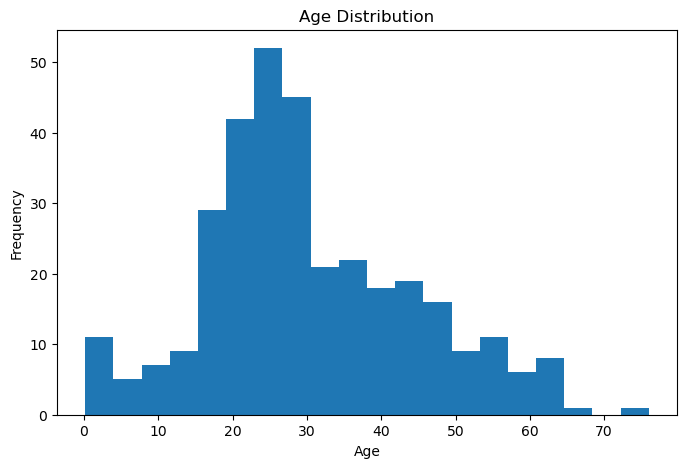

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'].dropna(), bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

#### Observation
- Most passengers were between 20 and 40 years old.
- Very young and very old passengers were fewer in number.

## 2️⃣ Fare Distribution (Boxplot)

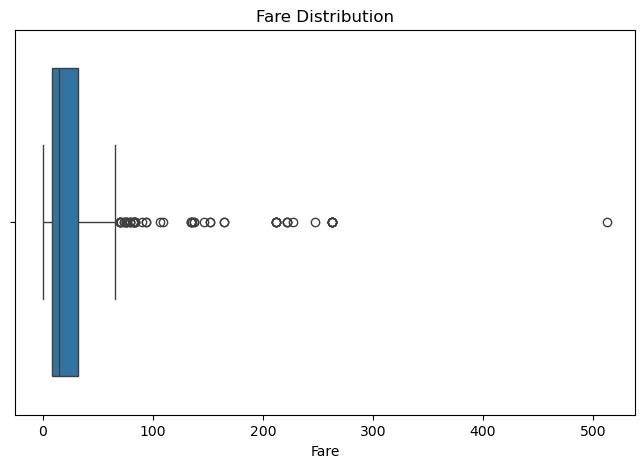

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.show()

#### Observation
- Ticket fares vary significantly among passengers.
- Several high-fare outliers are present.

## Phase 4: Bivariate Analysis

## 3️⃣ Age vs Fare (Scatterplot)

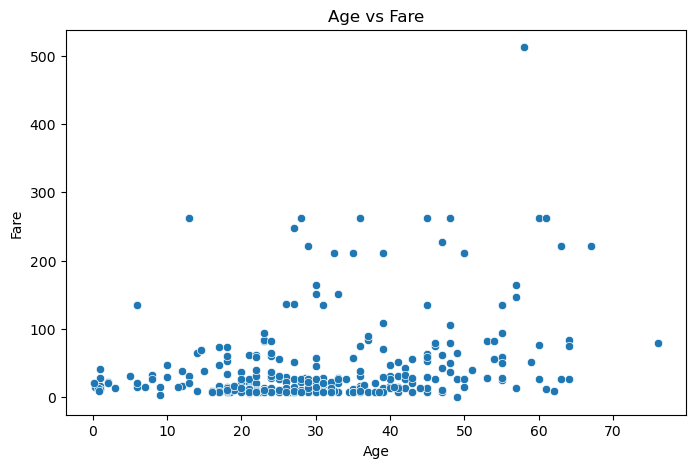

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Fare', data=df)
plt.title('Age vs Fare')
plt.show()

#### Observation
- No strong relationship exists between Age and Fare.
- Passengers of similar ages paid different ticket fares.

## 4️⃣ Survival by Gender

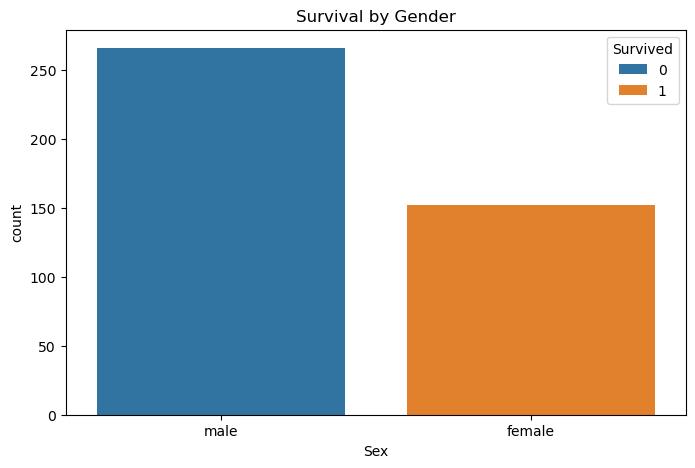

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.show()

#### Observation
- Female passengers had a higher survival rate.
- Male passengers had a lower survival rate compared to females.

## 5️⃣ Survival by Passenger Class

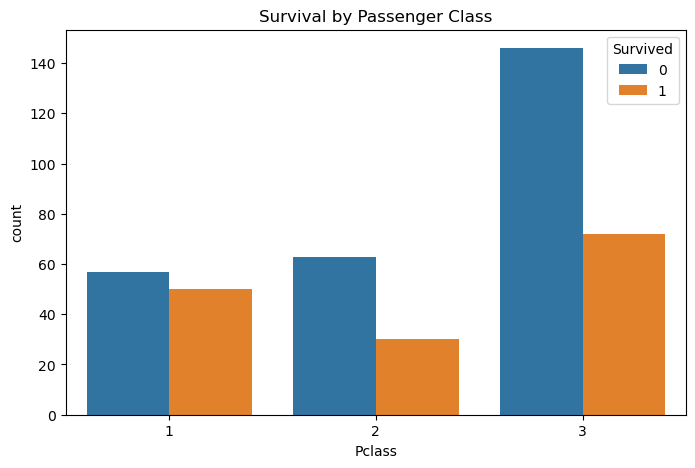

In [20]:
plt.figure(figsize=(8,5))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival by Passenger Class')
plt.show()

#### Observation
- First-class passengers had better survival chances.
- Third-class passengers experienced the highest number of deaths.

# Phase 5: Correlation Analysis

## 6️⃣ Correlation Heatmap

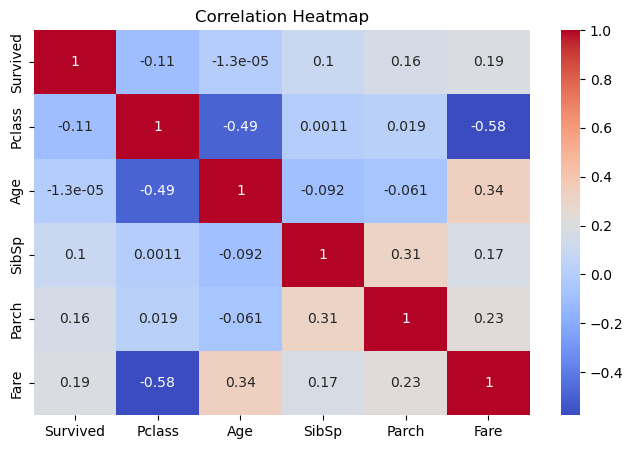

In [21]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Survived','Pclass','Age','SibSp','Parch','Fare']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

#### Observation
- Fare shows a positive relationship with survival.
- Passenger class is negatively correlated with survival.

#### 
1. Fare showed a positive relationship with survival (0.19), indicating that passengers paying higher fares had slightly better survival chances.

2. Passenger class showed a negative relationship with survival (-0.11), suggesting that lower-class passengers had lower survival rates.

3. The strongest relationship was observed between Pclass and Fare (-0.58), indicating that higher-class passengers generally paid higher ticket fares.

4. Age showed only a weak relationship with survival and fare.

## 7️⃣ Pairplot

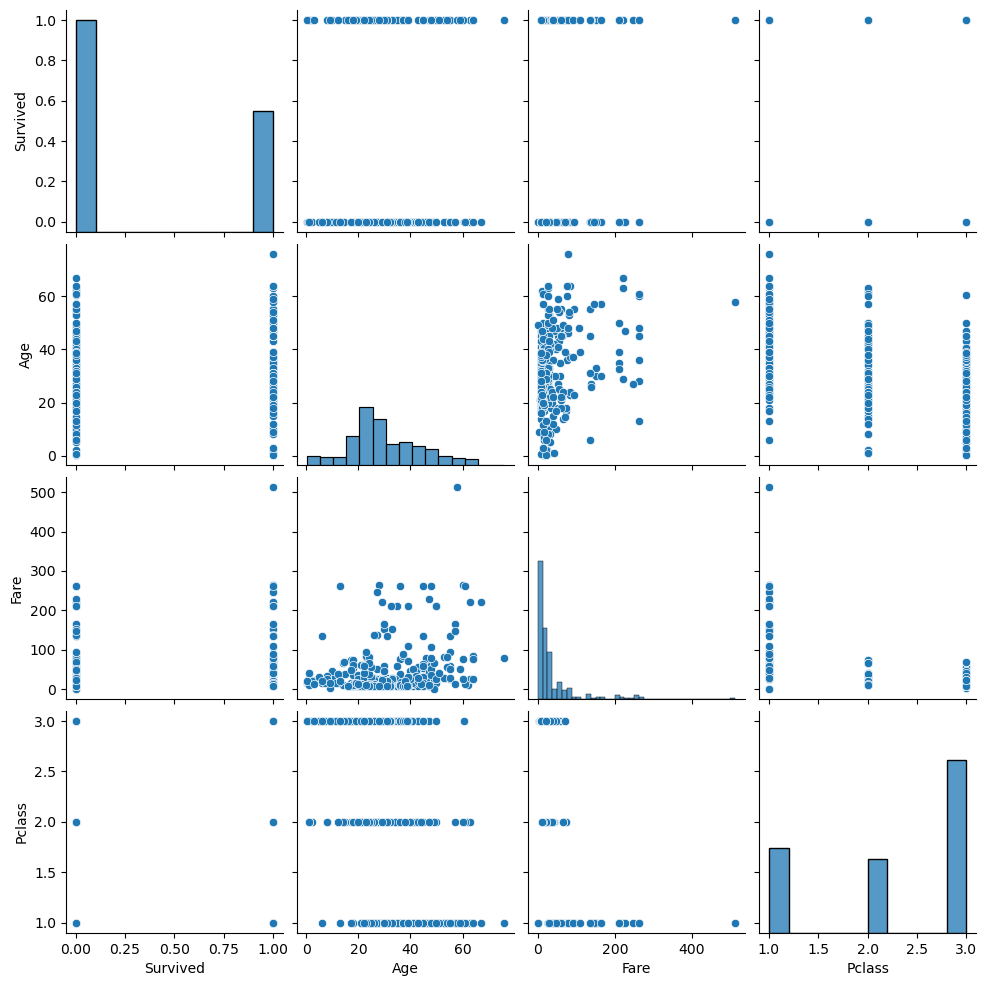

In [22]:
sns.pairplot(
    df[['Survived','Age','Fare','Pclass']]
)

plt.show()

#### Observation
- Survival patterns vary across Fare and Passenger Class.
- Pairplot helps visualize relationships among multiple variables simultaneously.

## FINAL OBSERVATION
1. Most passengers were between 20 and 40 years old.
2. Ticket fares contained several outliers.
3. Female passengers had higher survival rates than males.
4. First-class passengers had better chances of survival.
5. Fare and Survival showed a positive relationship.
6. Passenger Class significantly influenced survival outcomes.
7. Pairplot revealed clear patterns between Fare, Class, and Survival.

# -- END task -- 